In [3]:
!pip install dagshub mlflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 kB 7.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 73.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 71.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 43.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━

In [4]:

import numpy as np
import pandas as pd
import mlflow
import dagshub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.feature_selection import SelectKBest, f_regression

dagshub.init(repo_owner='ndoda23', repo_name='MachineLearning---House-Prices', mlflow=True)

df_train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
df_test  = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=9cc325c7-de14-470b-9cc5-41eddacea54c&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=3a02aaa44026ff3fada245323e97cd9f28e8f980379617419eb03703d68b3111




Accessing as ndoda23

Initialized MLflow to track repo "ndoda23/MachineLearning---House-Prices"

Repository ndoda23/MachineLearning---House-Prices initialized!

# CLEANING

### cleaning ის ნაწილში ვცდი სხვადასხვა ვარიანტებს და ვარჩევ საუკეთესოს.


### პირველი ვარიანტია წავშალო ისეთი სვეტები, სადაც 90%+ null ია

/tmp/ipykernel_55/3413197006.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_data.index, y=missing_data.values, palette='viridis')


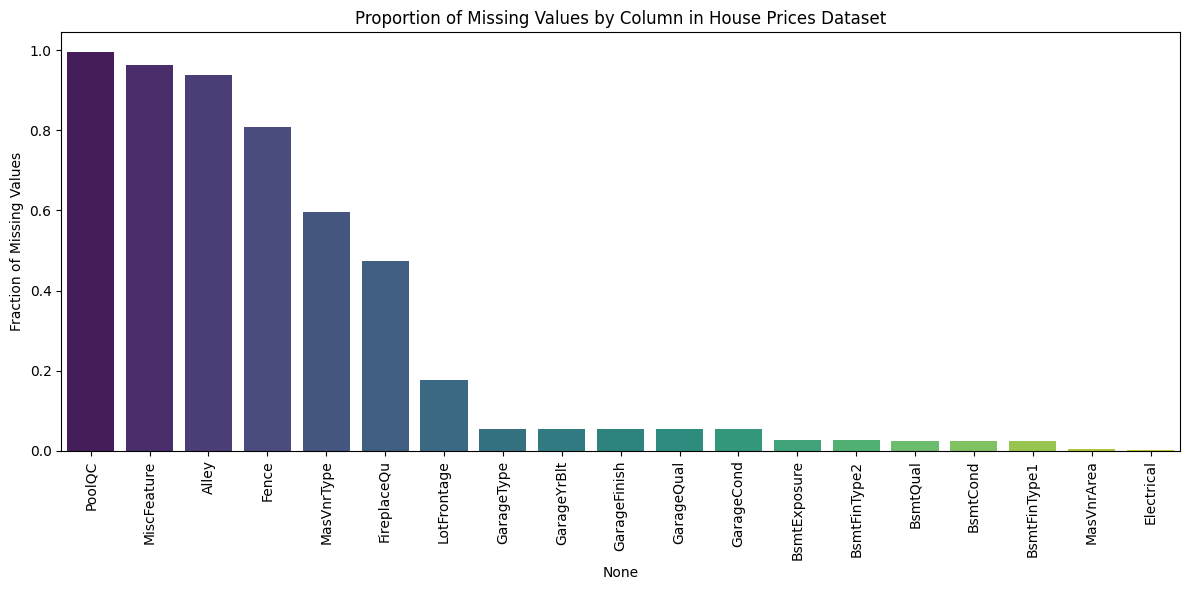

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np



missing_proportions = df_train.isnull().mean()

missing_data = missing_proportions[missing_proportions > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=missing_data.index, y=missing_data.values, palette='viridis')
plt.xticks(rotation=90)
plt.ylabel('Fraction of Missing Values')
plt.title('Proportion of Missing Values by Column in House Prices Dataset')
plt.tight_layout() 
plt.show()

In [4]:
# ============================================================
# 2. CLEANING 
# ============================================================

#X_train, X_val, y_train, y_val = train_test_split(
#    X, y, test_size=0.2, random_state=42
#)

#df_train = df_train.drop(columns=['Id'])

#high_null_cols = ['Alley', 'PoolQC', 'MiscFeature', 'Fence']
#df_train = df_train.drop(columns=high_null_cols)

#y = np.log1p(df_train['SalePrice'])
#X = df_train.drop(columns=['SalePrice'])


#print(f"Train: {X_train.shape}, Val: {X_val.shape}")

### მეორე ვარიანტია არ წავშალო არცერთი სვეტი

In [5]:
df_full = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
df_full['TotalSF'] = df_full['TotalBsmtSF'] + df_full['1stFlrSF'] + df_full['2ndFlrSF']
df_full['TotalBathrooms'] = (df_full['FullBath'] + (0.5 * df_full['HalfBath']) + 
                             df_full['BsmtFullBath'] + (0.5 * df_full['BsmtHalfBath']))
df_full['HouseAge'] = df_full['YrSold'] - df_full['YearBuilt']

X_full = df_full.drop(columns=['Id', 'SalePrice'])
y_full = np.log1p(df_full['SalePrice'])

X_train_full, X_val_full, y_train_full, y_val_full = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

print(f"Full Train: {X_train_full.shape}, Full Val: {X_val_full.shape}")

Full Train: (1168, 82), Full Val: (292, 82)


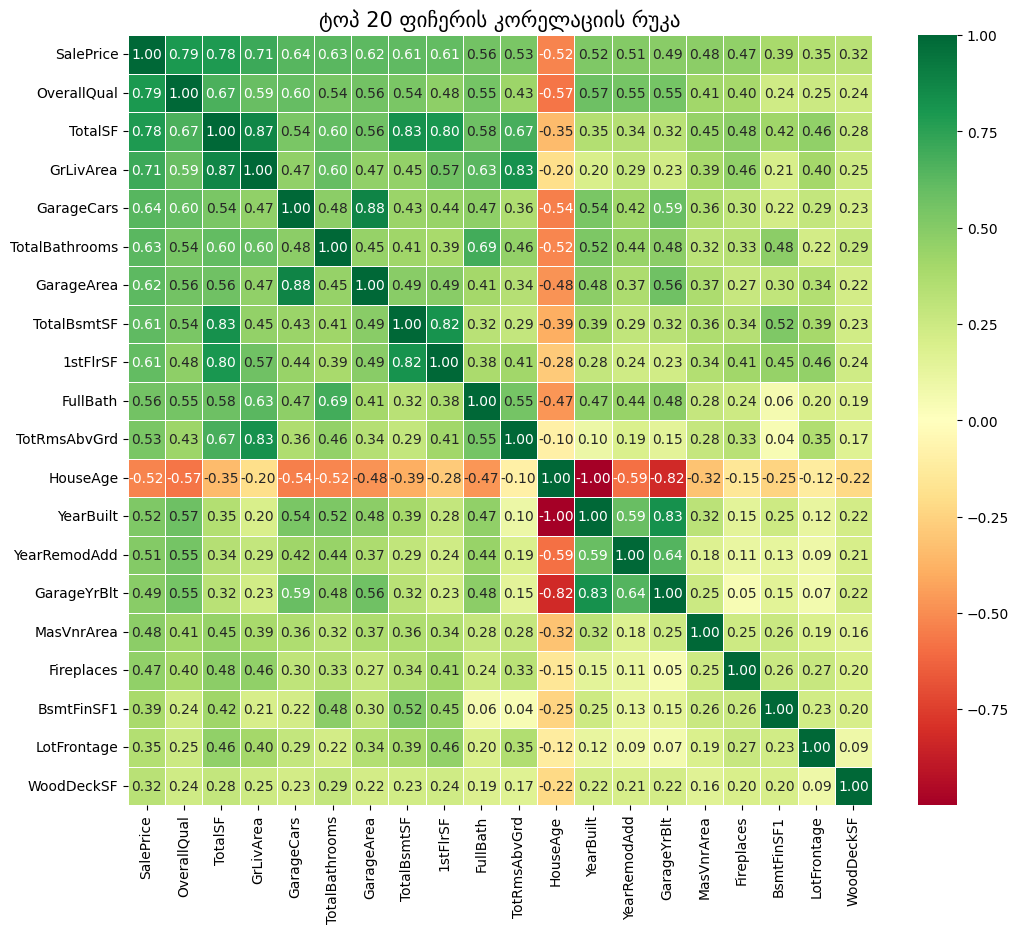

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_top_correlations(df, target_col='SalePrice', n=20):
    numeric_df = df.select_dtypes(include=[np.number])
    
    corr_matrix = numeric_df.corr()
    
    top_corr_features = corr_matrix[target_col].abs().sort_values(ascending=False).head(n).index
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(df[top_corr_features].corr(), annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
    plt.title(f'ტოპ {n} ფიჩერის კორელაციის რუკა', fontsize=15)
    plt.show()

plot_top_correlations(df_full) 

# FEATURE ENGINEERING

In [7]:
# ეს 

In [8]:
# ============================================================
# 3. FEATURE ENGINEERING 
# ============================================================
#cat_cols = X_train.select_dtypes(include='object').columns.tolist()
#num_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()

#num_imputer = SimpleImputer(strategy='median')
#cat_imputer = SimpleImputer(strategy='most_frequent')

#X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
#X_val[num_cols]   = num_imputer.transform(X_val[num_cols])      # transform only!

#X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
#X_val[cat_cols]   = cat_imputer.transform(X_val[cat_cols])

# --- One-hot encoding ---
#X_train = pd.get_dummies(X_train)
#X_val   = pd.get_dummies(X_val)
#X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)

# --- Scaling ---
#scaler = StandardScaler()
#X_train_scaled = scaler.fit_transform(X_train)   # fit+transform
#X_val_scaled   = scaler.transform(X_val)         # transform only!

In [9]:
cat_cols_f = X_train_full.select_dtypes(include='object').columns.tolist()
num_cols_f = X_train_full.select_dtypes(include=['int64','float64']).columns.tolist()

num_imputer_f = SimpleImputer(strategy='median')
cat_imputer_f = SimpleImputer(strategy='most_frequent')

X_train_full[num_cols_f] = num_imputer_f.fit_transform(X_train_full[num_cols_f])
X_val_full[num_cols_f]   = num_imputer_f.transform(X_val_full[num_cols_f])

X_train_full[cat_cols_f] = cat_imputer_f.fit_transform(X_train_full[cat_cols_f])
X_val_full[cat_cols_f]   = cat_imputer_f.transform(X_val_full[cat_cols_f])

X_train_full_enc = pd.get_dummies(X_train_full)
X_val_full_enc   = pd.get_dummies(X_val_full)

X_train_full_enc, X_val_full_enc = X_train_full_enc.align(X_val_full_enc, join='left', axis=1, fill_value=0)

scaler_f = StandardScaler()
X_train_full_scaled = scaler_f.fit_transform(X_train_full_enc)
X_val_full_scaled   = scaler_f.transform(X_val_full_enc)

print(f"ენკოდინგის შემდეგ სვეტების რაოდენობა: {X_train_full_scaled.shape[1]}")

ენკოდინგის შემდეგ სვეტების რაოდენობა: 288


# FEATURE SELECTION

In [10]:
def select_and_scale(X_train_df, X_val_df, y_train_series, threshold=0.1):
    temp_df = X_train_df.copy()
    temp_df['Target'] = y_train_series.values
    
    corrs = temp_df.corr()['Target'].abs().sort_values(ascending=False)
    
    selected_features = corrs[corrs > threshold].index.tolist()
    if 'Target' in selected_features:
        selected_features.remove('Target')
        
    print(f"🎯 Threshold {threshold}-ით 285 სვეტიდან დაგვრჩა {len(selected_features)} სვეტი.")
    
    X_tr_sel = X_train_df[selected_features]
    X_vl_sel = X_val_df[selected_features]
    
    sc = StandardScaler()
    X_tr_scaled = sc.fit_transform(X_tr_sel)
    X_vl_scaled = sc.transform(X_vl_sel)
    
    return X_tr_scaled, X_vl_scaled, len(selected_features)


X_train_final_scaled, X_val_final_scaled, n_features = select_and_scale(
    X_train_full_enc, 
    X_val_full_enc, 
    y_train_full, 
    threshold=0.089
)



🎯 Threshold 0.089-ით 285 სვეტიდან დაგვრჩა 146 სვეტი.


In [11]:
def get_high_corr_cols(X_df, y_series, threshold=0.8):
    corr_matrix = X_df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    to_drop = []
    target_corr = X_df.corrwith(y_series).abs()
    
    for column in upper.columns:
        high_corr_pairs = upper.index[upper[column] > threshold].tolist()
        for pair in high_corr_pairs:
            if target_corr[column] > target_corr[pair]:
                if pair not in to_drop: to_drop.append(pair)
            else:
                if column not in to_drop: to_drop.append(column)
    return list(set(to_drop))

X_train_refined = X_train_full_enc.copy()
X_val_refined = X_val_full_enc.copy()

cols_to_drop_auto = get_high_corr_cols(X_train_refined, y_train_full, threshold=0.8)
X_train_refined.drop(columns=cols_to_drop_auto, inplace=True)
X_val_refined.drop(columns=cols_to_drop_auto, inplace=True)


X_tr_final, X_vl_final, n_feat = select_and_scale(
    X_train_refined, 
    X_val_refined, 
    y_train_full, 
    threshold=0.083
)



🎯 Threshold 0.083-ით 285 სვეტიდან დაგვრჩა 126 სვეტი.


## RFE

In [12]:
possible_dfs = [var for var, obj in locals().items() if isinstance(obj, pd.DataFrame) and obj.shape[1] == 288]

if possible_dfs:
    correct_df_name = possible_dfs[0]
    print(f"ნაპოვნია სწორი DataFrame: {correct_df_name}")
    column_names = locals()[correct_df_name].columns
else:
   
    column_names = X_train_full_scaled_before.columns 
    
import pandas as pd
X_train_rfe_base = pd.DataFrame(X_train_full_scaled, columns=column_names)
X_val_rfe_base = pd.DataFrame(X_val_full_scaled, columns=column_names)

from sklearn.feature_selection import RFE
from sklearn.linear_model import Ridge

rfe = RFE(estimator=Ridge(alpha=15.0), n_features_to_select=80, step=5)
rfe.fit(X_train_rfe_base, y_train_full)

selected_columns = X_train_rfe_base.columns[rfe.support_]
X_train_rfe = X_train_rfe_base[selected_columns]
X_val_rfe = X_val_rfe_base[selected_columns]

print(f"RFE-მ წარმატებით დატოვა {len(selected_columns)} საუკეთესო ფიჩერი!")

ნაპოვნია სწორი DataFrame: X_train_full_enc
RFE-მ წარმატებით დატოვა 80 საუკეთესო ფიჩერი!


# გრაფიკები , ნახაზები 

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import io
import mlflow

def plot_actual_vs_predicted(y_true, y_pred, run_name):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.scatter(y_true, y_pred, alpha=0.5, color='royalblue', label='პრედიქციები')
    
    max_val = max(max(y_true), max(y_pred))
    min_val = min(min(y_true), min(y_pred))
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='იდეალური ხაზი')
    
    ax.set_title(f'რეალური vs ნაპროგნოზები ფასები - {run_name}')
    ax.set_xlabel('რეალური ფასი (Log Scale)')
    ax.set_ylabel('ნაპროგნოზები ფასი (Log Scale)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)
    
    return fig

In [14]:
def plot_residuals(y_true, y_pred, run_name):
    residuals = y_true - y_pred
    plt.figure(figsize=(10, 6))
    plt.scatter(y_pred, residuals, alpha=0.5, color='purple')
    plt.axhline(y=0, color='black', linestyle='--')
    plt.title(f'Residual Plot (შეცდომების განაწილება) - {run_name}')
    plt.xlabel('ნაპროგნოზები ფასები')
    plt.ylabel('შეცდომა (Residuals)')
    plt.grid(True, alpha=0.3)
    
    return plt.gcf()

In [15]:
def plot_feature_importance(model, feature_names, run_name):
    coefs = pd.Series(model.coef_, index=feature_names).abs().sort_values(ascending=False).head(15)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x=coefs.values, y=coefs.index, palette="rocket")
    plt.title(f'ტოპ 15 ყველაზე გავლენიანი ფიჩერი - {run_name}')
    plt.xlabel('კოეფიციენტის მნიშვნელობა (Importance)')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    return plt.gcf()

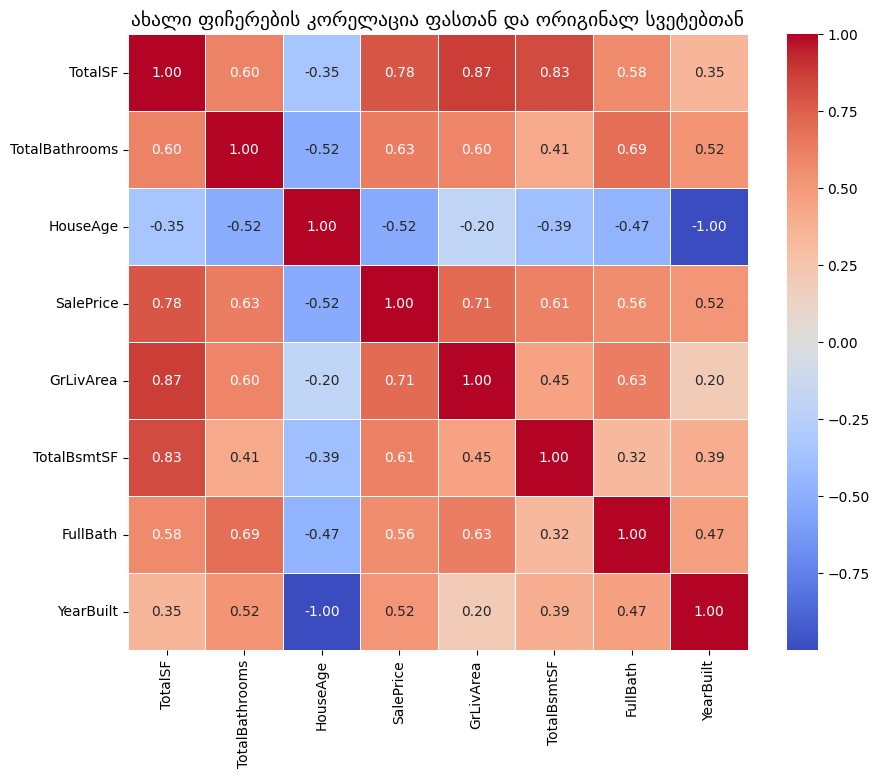

In [16]:
def plot_new_features_correlation(df):
    new_features = ['TotalSF', 'TotalBathrooms', 'HouseAge', 'SalePrice']
    
    comparison_cols = ['GrLivArea', 'TotalBsmtSF', 'FullBath', 'YearBuilt']
    
    cols_to_plot = new_features + [c for c in comparison_cols if c in df.columns]
    
    corr_matrix = df[cols_to_plot].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title('ახალი ფიჩერების კორელაცია ფასთან და ორიგინალ სვეტებთან', fontsize=14)
    plt.show()

plot_new_features_correlation(df_full)

# TRAINING AND MLFLOW LOGS

In [18]:
def run_experiment(X_train_data, X_val_data, y_train_data, y_val_data, run_name, 
                   model_type="LinearRegression", **kwargs):
    with mlflow.start_run(run_name=run_name) as run: 
        
        if model_type == "Ridge":
            model = Ridge(**kwargs)
        elif model_type == "DecisionTree":
            model = DecisionTreeRegressor(random_state=42, **kwargs)
        elif model_type == "RandomForest":
            model = RandomForestRegressor(random_state=42, **kwargs)
        elif model_type == "GradientBoosting": 
            model = GradientBoostingRegressor(**kwargs)
        else:
            model = LinearRegression()
        
        mlflow.log_params(kwargs)
        mlflow.log_param("model_type", model_type)
        
        model.fit(X_train_data, y_train_data)
        
        val_preds = model.predict(X_val_data)
        train_preds = model.predict(X_train_data)
        val_rmsle = np.sqrt(mean_squared_error(y_val_data, val_preds))
        train_rmsle = np.sqrt(mean_squared_error(y_train_data, train_preds))
        
        mlflow.log_metric("RMSLE", val_rmsle)
        mlflow.log_metric("train_RMSLE", train_rmsle)

        mlflow.sklearn.log_model(model, "model")
        
        print(f"🚀 {run_name} | Val RMSLE: {val_rmsle:.4f} | მოდელი დალოგილია!")
        
        fig = plot_actual_vs_predicted(y_val_data, val_preds, run_name)
        mlflow.log_figure(fig, "actual_vs_predicted.png")
        plt.close(fig)
        
        return run.info.run_id
       
    

from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 4, 5, 6, 8, 10, 12],
    'min_samples_leaf': [1, 2, 5, 10],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,                
    scoring='neg_mean_squared_error', 
    n_jobs=-1             
)

grid_search.fit(X_tr_final, y_train_full)

best_params = grid_search.best_params_

from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    'n_estimators': [100, 200],    
    'max_depth': [10, 15, 20, None],
    'max_features': ['sqrt', 'log2'], 
    'min_samples_leaf': [1, 2, 4]    
} 

rf_param_grid = {
    'n_estimators': [100, 200],     
    'max_depth': [10, 15, 20, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_leaf': [1, 2, 4] 
}

#  Best LinearRegression
# run_experiment(
#     X_tr_final, X_vl_final, y_train_full, y_val_full, 
#     run_name="Best_LinearRegression_Corr_0.089", 
#     model_type="LinearRegression" 
# )

#  Ridge 
# run_experiment(
#     X_tr_final, X_vl_final, y_train_full, y_val_full, 
#     run_name="Best_Model_Ridge", 
#     model_type="Ridge", 
#     alpha=15.0
# )

#  Decision Tree 
# run_experiment(
#     X_tr_final, X_vl_final, y_train_full, y_val_full, 
#     run_name="BestBaseline_DecisionTree", 
#     model_type="DecisionTree", 
#     max_depth=5 
# )

#  Random Forest 
# run_experiment(
#     X_tr_final, X_vl_final, y_train_full, y_val_full, 
#     run_name="Best_Model_RF", 
#     model_type="RandomForest",
#     n_estimators=300, 
#     max_depth=12, 
#     max_features='sqrt', 
#     min_samples_leaf=5
# )

#  Gradient Boosting
# run_experiment(
#     X_tr_final, X_vl_final, y_train_full, y_val_full, 
#     run_name="BESTGBM_Regularized_Gap", 
#     model_type="GradientBoosting", 
#     n_estimators=1000, 
#     learning_rate=0.01, 
#     max_depth=3, 
#     subsample=0.8, 
#     max_features='sqrt', 
#     n_iter_no_change=50, 
#     random_state=42
# )


#  Ridge  with high alpha on RFE 
# run_experiment(
#     X_train_rfe, X_val_rfe, y_train_full, y_val_full, 
#     run_name="Ridge_RFE_Heavy(130)_Regularization", 
#     model_type="Ridge", 
#     alpha=130.0  
# )


best_run_id = run_experiment(
    X_train_rfe, X_val_rfe, y_train_full, y_val_full, 
    run_name="FINAL_CHAMPION_RIDGE", 
    model_type="Ridge", 
    alpha=130.0
)

2026/04/10 14:31:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 14:31:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🚀 FINAL_CHAMPION_RIDGE | Val RMSLE: 0.1234 | მოდელი დალოგილია!
🏃 View run FINAL_CHAMPION_RIDGE at: https://dagshub.com/ndoda23/MachineLearning---House-Prices.mlflow/#/experiments/0/runs/700134461e9a430ab329b276499b853b
🧪 View experiment at: https://dagshub.com/ndoda23/MachineLearning---House-Prices.mlflow/#/experiments/0


In [ ]:
grid_search.best_params_

In [ ]:
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    'n_estimators': [100, 200],      
    'max_depth': [10, 15, 20, None], 
    'max_features': ['sqrt', 'log2'], 
    'min_samples_leaf': [1, 2, 4]    
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=rf_param_grid,
    cv=3,                 
    scoring='neg_mean_squared_error',
    n_jobs=-1             
)

rf_grid.fit(X_tr_final, y_train_full)

print(f"Best RF Params: {rf_grid.best_params_}")

In [ ]:
print(X_train_rfe.columns.tolist())

In [ ]:
import pickle

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler_f, f)

print("saved")